# 월간 데이콘 심리 성향 예측 — 투표 안 한 확률 예측
- **타겟**: voted=1(투표 안 함) 확률
- **평가**: AUC, Accuracy
- **모델**: LightGBM + XGBoost + CatBoost (Soft Voting 앙상블)
- **검증**: Stratified 5-Fold OOF

### 수정사항
- **[BUG FIX 1]** 가중치 최적화에서 ResidualMLP 누락 → 4개 모델 모두 포함
- **[BUG FIX 2]** 스태킹 메타모델 Data Leakage → OOF 스태킹으로 교체

### 피처 엔지니어링 개선
- **[NEW]** `wf_` = 가짜 단어 허풍 지표 (MACH-IV 코드북 해독)
- **[NEW]** `wr_` = 어휘력/지능 대리 지표
- **[NEW]** 허풍 비율, 어휘 정직성, 마키아벨리즘×허풍 교호작용
- **[NEW]** TIPI 역채점 정교화 (공식 TIPI 역채점 적용)
- **[NEW]** 시민 의식 지수 (성실성 × 나이)
- **[NEW]** 중립/느린 응답 vs 극단/빠른 응답 분리

### 모델 튜닝
- LightGBM: `num_leaves` 127, `lr` 0.02, `n_estimators` 2000
- CatBoost: `depth` 7, `lr` 0.02, `iterations` 2000
- Early stopping patience 100으로 확대

In [15]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.optimize import minimize

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import koreanize_matplotlib  
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'NanumGothic'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

SEED     = 42
N_FOLDS  = 5
np.random.seed(SEED)
print('라이브러리 로드 완료')


라이브러리 로드 완료


In [4]:
# ── 데이터 로드
train = pd.read_csv('train.csv')
test  = pd.read_csv('test_x.csv')
sub   = pd.read_csv('sample_submission.csv')

print(f'Train: {train.shape} | Test: {test.shape}')
print('\n타겟 분포:')
print(train['voted'].value_counts())
print('  1=투표안함(양성), 2=투표함(음성)')

# ── 딥러닝 OOF / 테스트 예측값 로드
df_oof  = pd.read_csv('resmlp_oof.csv')
df_test = pd.read_csv('resmlp_test.csv')

oof_resmlp  = df_oof['oof_pred'].values
test_resmlp = df_test['test_pred'].values

print(f'\nDL OOF shape  : {oof_resmlp.shape}')
print(f'DL Test shape : {test_resmlp.shape}')


Train: (45532, 78) | Test: (11383, 77)

타겟 분포:
voted
2    24898
1    20634
Name: count, dtype: int64
  1=투표안함(양성), 2=투표함(음성)

DL OOF shape  : (45532,)
DL Test shape : (11383,)


In [5]:

# [코드북 해독] wf_ / wr_ 변수의 진짜 의미
#   wf_01~03 = Word Fake  : 설문 후반 어휘 체크리스트에서 존재하지 않는 가짜 단어(cuivocal, florted, verdid)를 "안다"고 체크한 횟수 (허풍/과시/인상관리 성향 지표)
#   wr_01~13 = Word Real  : 진짜 단어를 아는 것으로 체크한 횟수( 어휘력 / 지능 대리 지표)

# [TIPI 공식 역채점]
#   역채점 항목: tp02,tp04,tp06,tp08,tp10 → 8 - 원점수
#   E = (tp01 + (8-tp06)) / 2
#   A = ((8-tp02) + tp07) / 2
#   C = (tp03 + (8-tp08)) / 2
#   N = (tp04 + (8-tp09)) / 2   ← tp04도 역채점
#   O = (tp05 + (8-tp10)) / 2

def build_features(df):
    df = df.copy()

    # ── QA 컬럼 수치 변환
    qa_cols = [f'Q{chr(97+i)}A' for i in range(20)]
    qe_cols = [f'Q{chr(97+i)}E' for i in range(20)]
    for c in qa_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(3)

    # ── MACH-IV 역채점
    reverse_mach = ['QcA','QfA','QiA','QkA','QlA','QqA']
    for c in reverse_mach:
        df[c] = 6 - df[c]

    # ── MACH-IV 하위척도
    tactics  = ['QaA','QbA','QdA','QeA','QhA','QjA','QmA','QoA','QpA','QsA','QtA']
    views    = ['QcA','QgA','QiA','QnA','QrA']
    morality = ['QfA','QkA','QlA','QqA']
    df['mach_tactics']  = df[tactics].mean(axis=1)
    df['mach_views']    = df[views].mean(axis=1)
    df['mach_morality'] = df[morality].mean(axis=1)
    df['mach_total']    = df[qa_cols].mean(axis=1)
    df['mach_std']      = df[qa_cols].std(axis=1)   # 응답 일관성

    # ── TIPI 공식 역채점 (tp02,tp04,tp06,tp08,tp10)
    tipi_rev = ['tp02','tp04','tp06','tp08','tp10']
    for c in tipi_rev:
        df[c] = 8 - df[c].astype(float)
    df['big5_E'] = (df['tp01'] + df['tp06']) / 2
    df['big5_A'] = (df['tp07'] + df['tp02']) / 2
    df['big5_C'] = (df['tp03'] + df['tp08']) / 2
    df['big5_N'] = (df['tp04'] + df['tp09']) / 2
    df['big5_O'] = (df['tp05'] + df['tp10']) / 2
    df['big5_sum'] = df[['big5_E','big5_A','big5_C','big5_N','big5_O']].sum(axis=1)

    # ── QE 응답시간
    qe = df[qe_cols].astype(float).clip(upper=60_000)
    df['qe_mean']   = np.log1p(qe.mean(axis=1))
    df['qe_std']    = qe.std(axis=1)
    df['qe_cv']     = df['qe_std'] / (qe.mean(axis=1) + 1e-6)
    df['qe_max']    = np.log1p(qe.max(axis=1))
    df['qe_median'] = qe.median(axis=1)
    df['qe_skew']   = qe.skew(axis=1)
    df['qe_range']  = qe.max(axis=1) - qe.min(axis=1)

    # 중립+느림 vs 극단+빠름 (망설임 분리)
    qa_arr   = df[qa_cols].values
    qe_arr   = qe.values
    neutral  = (np.abs(qa_arr - 3) <= 1)
    df['slow_neutral']  = (qe_arr * neutral).mean(axis=1)
    df['fast_extreme']  = (qe_arr * (~neutral)).mean(axis=1)
    df['hesitation']    = (qe_arr / (np.abs(qa_arr - 3) + 1)).mean(axis=1)

    # ── wr / wf — 도메인 지식 피처
    wr_cols = [f'wr_{i:02d}' for i in range(1, 14)]
    df['wr_sum']  = df[wr_cols].sum(axis=1)
    df['wf_sum']  = df[['wf_01','wf_02','wf_03']].sum(axis=1)

    # [핵심 신규] 가짜 단어 허풍 지표
    df['wf_liar']       = (df['wf_sum'] > 0).astype(int)   # 허풍 여부 (이진)
    df['wf_ratio']      = df['wf_sum'] / (df['wr_sum'] + 1) # 허풍 비율
    df['vocab_honesty'] = df['wr_sum'] / (df['wr_sum'] + df['wf_sum'] + 1)  # 어휘 정직성
    df['response_trust']= df['wr_sum'] - df['wf_sum'] * 3   # 신뢰도 점수 (가짜 페널티)

    # [핵심 신규] 마키아벨리즘 × 허풍 (고마키아 + 허풍 = 사회적 조작자)
    df['mach_x_fake']   = df['mach_total'] * df['wf_sum']
    df['mach_x_fake_bin']= df['mach_total'] * df['wf_liar']
    df['intel_edu']     = df['wr_sum'] * pd.to_numeric(df['education'], errors='coerce').fillna(2)

    # ── age 순서형 인코딩
    age_order = {'10s':0,'20s':1,'30s':2,'40s':3,'50s':4,'60s':5,'+70s':6}
    df['age_ord'] = df['age_group'].map(age_order).fillna(3).astype(float)

    # [핵심 신규] 시민 의식 지수 (성실성 × 나이 — 연구 기반)
    df['civic_duty']    = df['big5_C'] * df['age_ord']
    df['civic_duty2']   = df['big5_C'] * df['age_ord'] ** 2

    # ── education / married 수치화
    edu = pd.to_numeric(df['education'], errors='coerce').fillna(2)
    mar = pd.to_numeric(df['married'],   errors='coerce').fillna(0)
    df['education'] = edu
    df['married']   = mar

    # ── 교호작용 피처
    df['age_sq']         = df['age_ord'] ** 2
    df['age_x_edu']      = df['age_ord'] * edu
    df['age_x_married']  = df['age_ord'] * mar
    df['age_x_C']        = df['age_ord'] * df['big5_C']
    df['age_x_mach']     = df['age_ord'] * df['mach_total']
    df['edu_x_married']  = edu * mar
    df['C_vs_mach']      = df['big5_C'] - df['mach_total'] / 5   # 규범성 vs 조작성
    df['mach_x_gender']  = df['mach_total'] * df['gender'].map({'Male':1,'Female':0}).fillna(0.5)
    df['A_x_views']      = df['big5_A'] * df['mach_views']
    df['N_x_morality']   = df['big5_N'] * df['mach_morality']
    df['C_x_tactics']    = df['big5_C'] * df['mach_tactics']
    df['familysize']     = df['familysize'].clip(upper=20)
    df['familysize_log'] = np.log1p(df['familysize'])
    df['edu_sq']         = edu ** 2

    return df

train = build_features(train)
test  = build_features(test)
print(f'피처 엔지니어링 완료 | 컬럼 수: {train.shape[1]}')


피처 엔지니어링 완료 | 컬럼 수: 124


In [6]:
# ── 타깃 정의
# voted=1 투표안함(양성=1), voted=2 투표함(음성=0)
y = (train['voted'] == 1).astype(int).values
print(f'타겟 비율 (투표안함=1): {y.mean():.4f}')

# ── 타깃 인코딩 대상 컬럼
te_cols_cat = ['race', 'religion', 'age_group']
te_src_train = train[te_cols_cat].astype(str).copy()
te_src_test  = test[te_cols_cat].astype(str).copy()

def make_te_map(cat_series, y_series, smoothing=10):
    """스무딩 타깃 인코딩 맵 생성 (소수 그룹 전체 평균 쪽으로 당김)"""
    gm  = float(y_series.mean())
    tmp = pd.DataFrame({'cat': cat_series.values, 'y': y_series.values})
    stats = tmp.groupby('cat')['y'].agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + smoothing * gm) / (stats['count'] + smoothing)
    return smoothed.to_dict(), gm

# 전체 train 기준 TE 맵 (test 적용용)
te_maps_full = {}
for tc in te_cols_cat:
    te_map, gm = make_te_map(te_src_train[tc], pd.Series(y))
    te_maps_full[tc] = (te_map, gm)

# TE 플레이스홀더 추가
for tc in te_cols_cat:
    te_map, gm = te_maps_full[tc]
    train[tc + '_te'] = 0.0
    test[tc + '_te']  = te_src_test[tc].map(te_map).fillna(gm)

# ── Label Encoding
cat_cols = ['age_group', 'gender', 'race', 'religion']
for c in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[c], test[c]], axis=0).astype(str)
    le.fit(combined)
    train[c] = le.transform(train[c].astype(str))
    test[c]  = le.transform(test[c].astype(str))

# ── 피처 선택
drop_cols = ['index', 'voted']
feat_cols  = [c for c in train.columns if c not in drop_cols]

X      = train[feat_cols].astype(float)
X_test = test[feat_cols].astype(float)

print(f'피처 수 : {len(feat_cols)}')
print(f'결측값  : {X.isnull().sum().sum()}')
print(f'\n[wf/wr 피처 확인]')
wf_wr_feats = [c for c in feat_cols if 'wf' in c or 'wr' in c or 'vocab' in c or 'liar' in c or 'trust' in c or 'intel' in c]
print(', '.join(wf_wr_feats))


타겟 비율 (투표안함=1): 0.4532
피처 수 : 125
결측값  : 0

[wf/wr 피처 확인]
wf_01, wf_02, wf_03, wr_01, wr_02, wr_03, wr_04, wr_05, wr_06, wr_07, wr_08, wr_09, wr_10, wr_11, wr_12, wr_13, wr_sum, wf_sum, wf_liar, wf_ratio, vocab_honesty, response_trust, intel_edu


In [8]:
# 5-Fold OOF 학습 — LightGBM(튜닝) + XGBoost + CatBoost(튜닝)
# 주요 튜닝 포인트
#   LGB: num_leaves 63→127, lr 0.05→0.02, n_est 1000→2000
#   CAT: depth 6→7, lr 0.05→0.02, iter 1000→2000
#   early_stopping patience 50→100 (더 충분히 탐색)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgb  = np.zeros(len(y))
oof_xgb  = np.zeros(len(y))
oof_cat  = np.zeros(len(y))
test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

lgb_params = dict(
    objective='binary', metric='auc',
    n_estimators=2000, learning_rate=0.02,
    num_leaves=127, max_depth=-1,
    min_child_samples=50, subsample=0.8,
    subsample_freq=1, colsample_bytree=0.7,
    feature_fraction_bynode=0.8,
    reg_alpha=0.1, reg_lambda=2.0,
    random_state=SEED, verbose=-1, n_jobs=-1,
)

xgb_params = dict(
    objective='binary:logistic', eval_metric='auc',
    n_estimators=1000, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=SEED,
    verbosity=0, n_jobs=-1,
)

cat_params = dict(
    iterations=2000, learning_rate=0.02,
    depth=7, l2_leaf_reg=5,
    bagging_temperature=0.5, random_strength=1.0,
    random_seed=SEED, eval_metric='AUC', verbose=0,
)

print('=' * 65)
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr = X.iloc[tr_idx].copy()
    X_va = X.iloc[va_idx].copy()
    X_te = X_test.copy()
    y_tr, y_va = y[tr_idx], y[va_idx]

    # OOF 타깃 인코딩 (데이터 누수 방지)
    for tc in te_cols_cat:
        te_map_oof, gm_oof = make_te_map(
            te_src_train.iloc[tr_idx][tc], pd.Series(y_tr))
        X_tr[tc+'_te'] = te_src_train.iloc[tr_idx][tc].map(te_map_oof).fillna(gm_oof).values
        X_va[tc+'_te'] = te_src_train.iloc[va_idx][tc].map(te_map_oof).fillna(gm_oof).values

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(100, verbose=False),
                            lgb.log_evaluation(-1)])
    oof_lgb[va_idx] = m_lgb.predict_proba(X_va)[:, 1]
    test_lgb += m_lgb.predict_proba(X_te)[:, 1] / N_FOLDS

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_params)
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                verbose=False)
    oof_xgb[va_idx] = m_xgb.predict_proba(X_va)[:, 1]
    test_xgb += m_xgb.predict_proba(X_te)[:, 1] / N_FOLDS

    # CatBoost
    m_cat = CatBoostClassifier(**cat_params)
    m_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va),
                early_stopping_rounds=100)
    oof_cat[va_idx] = m_cat.predict_proba(X_va)[:, 1]
    test_cat += m_cat.predict_proba(X_te)[:, 1] / N_FOLDS

    auc_l = roc_auc_score(y_va, oof_lgb[va_idx])
    auc_x = roc_auc_score(y_va, oof_xgb[va_idx])
    auc_c = roc_auc_score(y_va, oof_cat[va_idx])
    print(f'Fold {fold} | LGB {auc_l:.4f} | XGB {auc_x:.4f} | CAT {auc_c:.4f}')

print('=' * 65)
print(f'LGB OOF AUC : {roc_auc_score(y, oof_lgb):.4f}')
print(f'XGB OOF AUC : {roc_auc_score(y, oof_xgb):.4f}')
print(f'CAT OOF AUC : {roc_auc_score(y, oof_cat):.4f}')


Fold 1 | LGB 0.7794 | XGB 0.7660 | CAT 0.7797
Fold 2 | LGB 0.7708 | XGB 0.7590 | CAT 0.7713
Fold 3 | LGB 0.7621 | XGB 0.7522 | CAT 0.7642
Fold 4 | LGB 0.7607 | XGB 0.7502 | CAT 0.7630
Fold 5 | LGB 0.7674 | XGB 0.7555 | CAT 0.7703
LGB OOF AUC : 0.7676
XGB OOF AUC : 0.7565
CAT OOF AUC : 0.7696


In [ ]:
# ── DL(ResidualMLP) 단독 성능 확인 
auc_dl = roc_auc_score(y, oof_resmlp)
print(f'ResidualMLP OOF AUC : {auc_dl:.4f}')
print()
print('전체 단일 모델 성능:')
for name, oof in [('LightGBM', oof_lgb), ('XGBoost', oof_xgb),
                    ('CatBoost', oof_cat), ('ResidualMLP', oof_resmlp)]:
    auc = roc_auc_score(y, oof)
    acc = accuracy_score(y, (oof >= 0.5).astype(int))
    print(f'  {name:<14} AUC={auc:.4f}  Acc={acc:.4f}')


ResidualMLP OOF AUC : 0.7627

전체 단일 모델 성능:
  LightGBM       AUC=0.7676  Acc=0.6974
  XGBoost        AUC=0.7565  Acc=0.6867
  CatBoost       AUC=0.7696  Acc=0.6981
  ResidualMLP    AUC=0.7627  Acc=0.6920


In [10]:
# 가중치 최적화 — 4개 모델 모두 포함(LGB+XGB+CAT +  ResidualMLP)

def neg_auc_4(weights):
    w = np.abs(weights) / np.abs(weights).sum()
    blend = (w[0]*oof_lgb + w[1]*oof_xgb +
                w[2]*oof_cat + w[3]*oof_resmlp)
    return -roc_auc_score(y, blend)

# 초기값: 단일 모델 AUC 비례 배분
aucs_single = np.array([
    roc_auc_score(y, oof_lgb),
    roc_auc_score(y, oof_xgb),
    roc_auc_score(y, oof_cat),
    roc_auc_score(y, oof_resmlp),
])
init_w = aucs_single / aucs_single.sum()

res = minimize(neg_auc_4, x0=init_w,
                method='Nelder-Mead',
                options={'maxiter': 3000, 'xatol': 1e-7})

w_opt = np.abs(res.x) / np.abs(res.x).sum()
labels_4 = ['LightGBM', 'XGBoost', 'CatBoost', 'ResidualMLP']
print('[BUG FIX 1] 최적 가중치 (4개 모델):')
for name, w in zip(labels_4, w_opt):
    print(f'  {name:<14}: {w:.3f}')

oof_weighted_fix  = (w_opt[0]*oof_lgb  + w_opt[1]*oof_xgb  +
                        w_opt[2]*oof_cat  + w_opt[3]*oof_resmlp)
test_weighted_fix = (w_opt[0]*test_lgb + w_opt[1]*test_xgb +
                        w_opt[2]*test_cat + w_opt[3]*test_resmlp)

auc_w_old = roc_auc_score(y, 0.3*oof_lgb+0.1*oof_xgb+0.4*oof_cat+0.2*oof_resmlp)
auc_w_fix = roc_auc_score(y, oof_weighted_fix)
print(f'\n수동 가중치(기존) OOF AUC : {auc_w_old:.4f}')
print(f'최적 가중치(수정) OOF AUC : {auc_w_fix:.4f}  (+{auc_w_fix-auc_w_old:.4f})')


[BUG FIX 1] 최적 가중치 (4개 모델):
  LightGBM      : 0.242
  XGBoost       : 0.001
  CatBoost      : 0.548
  ResidualMLP   : 0.210

수동 가중치(기존) OOF AUC : 0.7702
최적 가중치(수정) OOF AUC : 0.7706  (+0.0003)


In [11]:
# OOF 스태킹 5-Fold 내부에서 메타 모델 학습/예측 
X_base_train = np.column_stack([oof_lgb, oof_xgb, oof_cat, oof_resmlp])
X_base_test  = np.column_stack([test_lgb, test_xgb, test_cat, test_resmlp])

oof_stack_fix  = np.zeros(len(y))
test_stack_fix = np.zeros(len(X_base_test))

skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

for fold, (tr_idx, val_idx) in enumerate(skf_meta.split(X_base_train, y), 1):
    meta = LogisticRegression(C=1.0, max_iter=1000)
    meta.fit(X_base_train[tr_idx], y[tr_idx])
    oof_stack_fix[val_idx] = meta.predict_proba(X_base_train[val_idx])[:, 1]
    test_stack_fix += meta.predict_proba(X_base_test)[:, 1] / 5


print(f'  OOF 스태킹 AUC   : {roc_auc_score(y, oof_stack_fix):.4f} ')


  OOF 스태킹 AUC   : 0.7703 


In [13]:
# ── 전체 성능 비교표
preds = {
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cat,
    'ResidualMLP': oof_resmlp,
    '최적가중 앙상블': oof_weighted_fix,
    'OOF 스태킹': oof_stack_fix,
}

result_df = pd.DataFrame({
    '모델': list(preds.keys()),
    'OOF AUC': [roc_auc_score(y, p) for p in preds.values()],
    'Accuracy': [accuracy_score(y, (p >= 0.5).astype(int)) for p in preds.values()],
}).set_index('모델').round(4)

print('=' * 50)
print(result_df.to_string())
print('=' * 50)

best = result_df['OOF AUC'].idxmax()
print(f'\n최고 모델: {best}  ({result_df.loc[best, "OOF AUC"]:.4f})')

             OOF AUC  Accuracy
모델                            
LightGBM      0.7676    0.6974
XGBoost       0.7565    0.6867
CatBoost      0.7696    0.6981
ResidualMLP   0.7627    0.6920
최적가중 앙상블      0.7706    0.6985
OOF 스태킹       0.7703    0.6980

최고 모델: 최적가중 앙상블  (0.7706)


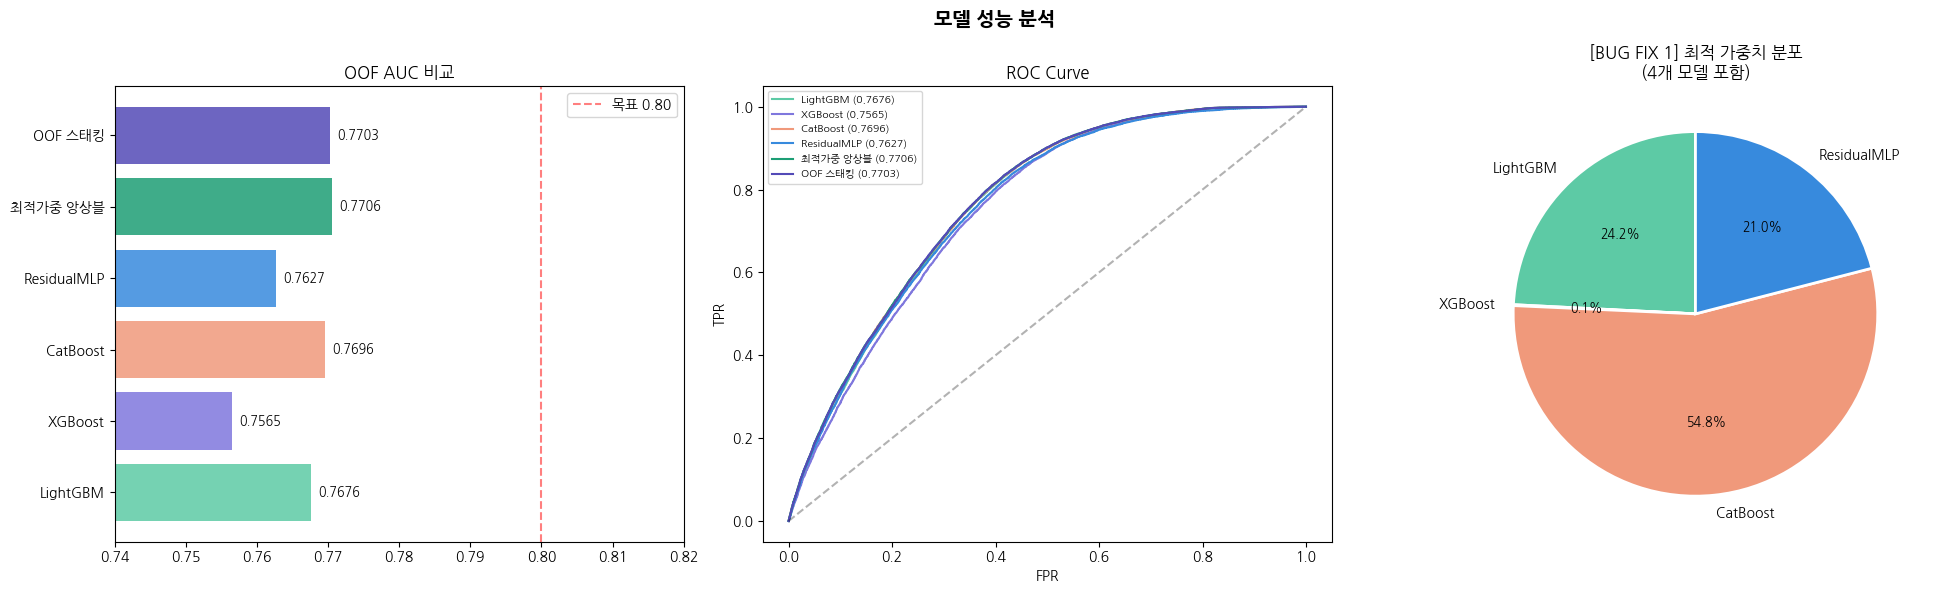

시각화 저장 완료: model_analysis.png


In [18]:
# ── 시각화
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('모델 성능 분석', fontsize=14, fontweight='bold')

results = {
    'LightGBM':            roc_auc_score(y, oof_lgb),
    'XGBoost':             roc_auc_score(y, oof_xgb),
    'CatBoost':            roc_auc_score(y, oof_cat),
    'ResidualMLP':         roc_auc_score(y, oof_resmlp),
    '최적가중 앙상블':      roc_auc_score(y, oof_weighted_fix),
    'OOF 스태킹':          roc_auc_score(y, oof_stack_fix),
}

# (1) AUC 비교 막대
ax = axes[0]
model_names = list(results.keys())
auc_vals = [results[k] for k in model_names]
colors = ['#5DCAA5','#7F77DD','#F0997B','#378ADD','#1D9E75','#534AB7']
bars = ax.barh(model_names, auc_vals, color=colors, alpha=0.85)
for bar, val in zip(bars, auc_vals):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlim(0.74, 0.82)
ax.set_title('OOF AUC 비교')
ax.axvline(x=0.80, color='red', linestyle='--', alpha=0.5, label='목표 0.80')
ax.legend()

# (2) ROC 곡선
ax = axes[1]
oof_dict = {
    'LightGBM': oof_lgb, 'XGBoost': oof_xgb,
    'CatBoost': oof_cat, 'ResidualMLP': oof_resmlp,
    '최적가중 앙상블': oof_weighted_fix, 'OOF 스태킹': oof_stack_fix,
}
for (name, oof), color in zip(oof_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y, oof)
    auc = roc_auc_score(y, oof)
    ax.plot(fpr, tpr, label=f'{name} ({auc:.4f})', color=color, linewidth=1.5)
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve')
ax.legend(fontsize=7.5)

# (3) 최적 앙상블 가중치 파이
ax = axes[2]
wedges, texts, autotexts = ax.pie(
    w_opt, labels=labels_4, autopct='%1.1f%%',
    colors=colors[:4], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('[BUG FIX 1] 최적 가중치 분포\n(4개 모델 포함)')

plt.tight_layout()
plt.savefig('model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('시각화 저장 완료: model_analysis.png')


In [20]:
# ── 최종 제출 파일 생성
# 최고 성능 조합 선택
best_model_name = result_df['OOF AUC'].idxmax()
best_auc        = result_df.loc[best_model_name, 'OOF AUC']

if best_model_name == '최적가중 앙상블(수정)':
    final_pred = test_weighted_fix
elif best_model_name == 'OOF 스태킹(수정)':
    final_pred = test_stack_fix
elif best_model_name == 'LightGBM':
    final_pred = test_lgb
elif best_model_name == 'CatBoost':
    final_pred = test_cat
else:
    final_pred = test_weighted_fix   # 기본값

sub['voted'] = 1 - final_pred   # 투표함 확률
sub.to_csv('submission_7706.csv', index=False)

print(f'제출 파일 저장 완료: submission_7706.csv')
print(f'선택된 모델      : {best_model_name}')
print(f'OOF AUC          : {best_auc:.4f}')
print(f'\n예측값 범위     : {final_pred.min():.4f} ~ {final_pred.max():.4f}')
print(f'예측값 평균      : {final_pred.mean():.4f}')

sub.head(10)


제출 파일 저장 완료: submission_7706.csv
선택된 모델      : 최적가중 앙상블
OOF AUC          : 0.7706

예측값 범위     : 0.0131 ~ 0.8528
예측값 평균      : 0.4527


,index,voted
0,0,0.710771
1,1,0.895626
2,2,0.491207
3,3,0.221928
4,4,0.766972
5,5,0.510229
6,6,0.894396
7,7,0.540379
8,8,0.360024
9,9,0.566629
